In [1]:
include("LST_BEK_vonKarmen.jl")

Main.io

In [2]:
using LinearAlgebra
using Arpack
using Statistics
using ProgressMeter

In [9]:

#————————test module————————#

N=99
α=0.44
β=0.1
R=300
Ro=-1
Co=2-Ro-Ro^2
A,B=KEB_TimeMode.KEB_LST_OS("Vonkarmen copy 2.txt",N,α,β,R)
@time C=eigen(A,B)
values=C.values
vectors=C.vectors
D=filter(x-> 0<imag(x)<0.1, values)
# K=map(x->0<imag(x)<0.1,values)
# K=filter(x-> 0<imag(x)<0.1 , values)
# if K==ComplexF64[]
#     K1=findmax(x-> imag(x)<0, values)
#     index=K1[2]
# else
#     K1=indexin(K,values)
#     index=K1
# end
#     c_temp=values[index[1],1]
#     q1=vectors[:,index[1]]
# c,q=KEBProblem.rayleigh_quotient_iteration(A,B,c_temp,q0=q1)
# c
# st=mean(real(values))
# c1=findall(x->real(x)<st,D)
# c=D[c1[1],1]

  0.018129 seconds (18 allocations: 496.922 KiB)


1-element Vector{ComplexF64}:
 -0.024164049460276206 + 0.007759401287579387im

In [ ]:
#25,50,75,100,125

In [ ]:
Ro=1
N=99
R=25
α_all=nothing
β_all=nothing
c_all=nothing
@showprogress 1 "Computing..."  for α=0.005:0.005:1
    for β=0.004:0.004:0.4
    A,B=KEB_TimeMode.KEB_LST_all("Bodewadt.txt",N,α,β,R,Ro)
     G=eigen(A,B)
     values=G.values
     vectors=G.vectors
     st=mean(real(values))
     D=filter(x-> 0<imag(x)<0.1, values)
        if D == ComplexF64[]
            c=-1-1*im
        else 
            c1=findall(x->real(x)<st,D)
            if c1==[]
                c=-1-1*im
            else
                c=D[c1[1],1]
            end
        end
        c_all=[c_all;c]
        α_all=[α_all;α]
        β_all=[β_all;β]
    end
end

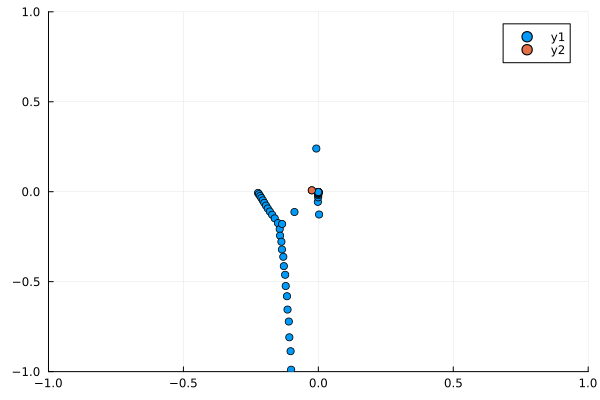

In [10]:
using Plots
scatter(real(values),imag(values),ylims=[-1,1],xlims=[-1,1])
scatter!(real(D),imag(D))

In [ ]:
α_all=α_all[2:end,1]
β_all=β_all[2:end,1]
c_all=c_all[2:end,1]

In [ ]:
data_imag=[α_all β_all imag(c_all)]
data_real=[α_all β_all real(c_all)]

In [ ]:
using DelimitedFiles
writedlm("Bodewadt_R=25_imag.dat",data_imag ,'\t')
writedlm("Bodewadt_R=25_real.dat",data_real ,'\t')